<a href="https://colab.research.google.com/github/GeerbaniShashi/Sololearn_Machine_Learning/blob/main/Random_Forest_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
from sklearn.datasets import load_breast_cancer

cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data['data'], columns = cancer_data['feature_names'])
df['target'] = cancer_data['target']

X = df[cancer_data.feature_names].values
y = df['target'].values
print("data dimensions", X.shape)

data dimensions (569, 30)


In [3]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data['data'], columns = cancer_data['feature_names'])
df['target'] = cancer_data['target']

X = df[cancer_data.feature_names].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 101)

rf = RandomForestClassifier()
rf.fit(X_train, y_train)

first_row = X_test[0]
print("prediction:", rf.predict([first_row]))
print("true value:", y_test[0])

prediction: [1]
true value: 1


In [4]:
print("accuracy:", rf.score(X_test, y_test))

accuracy: 0.972027972027972


In [5]:
from sklearn.tree import DecisionTreeClassifier
dt = DecisionTreeClassifier()
dt.fit(X_train, y_train)
print("accuracy:", dt.score(X_test, y_test))

accuracy: 0.9090909090909091


In [6]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data['data'], columns = cancer_data['feature_names'])
df['target'] = cancer_data['target']

X = df[cancer_data.feature_names].values
y = df['target'].values

param_grid = {
    'n_estimators': [10, 25, 50, 75, 100],
}

rf = RandomForestClassifier(random_state = 123)
gs = GridSearchCV(rf, param_grid, scoring = 'f1', cv = 5)
gs.fit(X, y)
print("best params:", gs.best_params_)

best params: {'n_estimators': 25}


In [7]:
n_estimators = list(range(1, 101))
param_grid = {
    'n_estimators': n_estimators,
}
rf = RandomForestClassifier()
gs = GridSearchCV(rf, param_grid, cv=5)
gs.fit(X, y)

GridSearchCV(cv=5, estimator=RandomForestClassifier(),
             param_grid={'n_estimators': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12,
                                          13, 14, 15, 16, 17, 18, 19, 20, 21,
                                          22, 23, 24, 25, 26, 27, 28, 29, 30, ...]})

In [8]:
scores = gs.cv_results_['mean_test_score']
print(scores)

[0.92271386 0.90335352 0.94902965 0.94553641 0.94552088 0.93851886
 0.95435491 0.94730632 0.94205869 0.96135693 0.94907623 0.95256948
 0.95079957 0.95433939 0.9561093  0.96488123 0.95784816 0.95607825
 0.95078404 0.95961807 0.95783263 0.96311132 0.96132588 0.95081509
 0.95961807 0.95784816 0.9561093  0.96312684 0.96309579 0.96135693
 0.952585   0.95784816 0.94730632 0.95960255 0.95958702 0.96663562
 0.9648657  0.9595715  0.96312684 0.96135693 0.96314237 0.9560472
 0.95960255 0.95955597 0.96488123 0.9595715  0.96485018 0.9648657
 0.96134141 0.95609377 0.95960255 0.96137246 0.96134141 0.95606272
 0.96489676 0.96311132 0.96134141 0.96137246 0.95961807 0.95784816
 0.96138798 0.96137246 0.96837448 0.95781711 0.95960255 0.95786369
 0.96311132 0.96488123 0.96662009 0.95958702 0.96312684 0.96662009
 0.95958702 0.95783263 0.96135693 0.96663562 0.96135693 0.95961807
 0.96311132 0.96134141 0.96312684 0.95960255 0.96662009 0.95961807
 0.96311132 0.96488123 0.96311132 0.96135693 0.9648657  0.963111

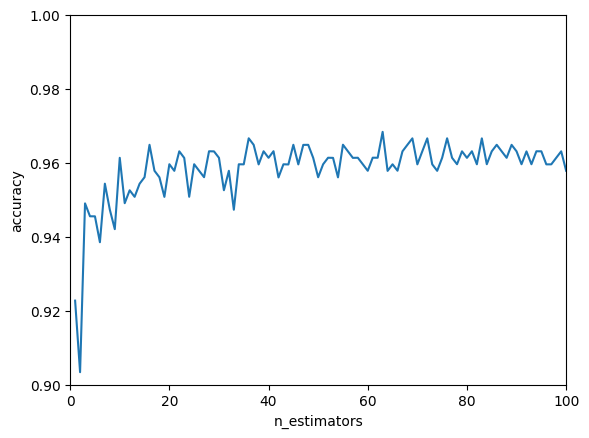

In [9]:
import matplotlib.pyplot as plt

scores = gs.cv_results_['mean_test_score']
plt.plot(n_estimators, scores)
plt.xlabel("n_estimators")
plt.ylabel("accuracy")
plt.xlim(0, 100)
plt.ylim(0.9, 1)
plt.show()

In [10]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data['data'], columns = cancer_data['feature_names'])
df['target'] = cancer_data['target']

X = df[cancer_data.feature_names].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 101)
rf = RandomForestClassifier(n_estimators = 10, random_state = 111)
rf.fit(X_train, y_train)

ft_imp = pd.Series(rf.feature_importances_, index=cancer_data.feature_names).sort_values(ascending=False)
print(ft_imp.head(10))

worst radius            0.309701
mean concave points     0.183126
worst concave points    0.115641
mean perimeter          0.064119
mean radius             0.058742
worst concavity         0.050951
radius error            0.049103
mean texture            0.017197
worst area              0.016512
mean concavity          0.014696
dtype: float64


In [11]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data['data'], columns = cancer_data['feature_names'])
df['target'] = cancer_data['target']

X = df[cancer_data.feature_names].values
y = df['target'].values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 101)
rf = RandomForestClassifier(n_estimators = 10, random_state = 111)
rf.fit(X_train, y_train)

print(rf.score(X_test, y_test))

0.965034965034965


In [13]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data['data'], columns = cancer_data['feature_names'])
df['target'] = cancer_data['target']
worst_cols = [col for col in df.columns if 'worst' in col]
print(worst_cols)

['worst radius', 'worst texture', 'worst perimeter', 'worst area', 'worst smoothness', 'worst compactness', 'worst concavity', 'worst concave points', 'worst symmetry', 'worst fractal dimension']


In [14]:
from sklearn.model_selection import train_test_split
X_worst = df[worst_cols]
X_train, X_test, y_train, y_test = train_test_split(X_worst, y, random_state = 101)

In [18]:
import pandas as pd
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

cancer_data = load_breast_cancer()
df = pd.DataFrame(cancer_data['data'], columns = cancer_data['feature_names'])
df['target'] = cancer_data['target']

X = df[cancer_data.feature_names].values
y = df['target'].values

rf = RandomForestClassifier(n_estimators = 10, random_state = 111)

worst_cols = [col for col in df.columns if 'worst' in col]
X_worst = df[worst_cols]
X_train, X_test, y_train, y_test = train_test_split(X_worst, y, random_state = 101)
rf.fit(X_train, y_train)

print(rf.score(X_test, y_test))

0.972027972027972


In [19]:
from sklearn.datasets import make_circles
from sklearn.model_selection import KFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import numpy as np

X, y = make_circles(noise = 0.2, factor = 0.5, random_state = 1)

kf = KFold(n_splits = 5, shuffle = True, random_state = 1)
lr_scores = []
rf_scores = []
for train_index, test_index in kf.split(X):
  X_train, X_test = X[train_index], X[test_index]
  y_train, y_test = y[train_index], y[test_index]
  lr = LogisticRegression(solver = 'lbfgs')
  lr.fit(X_train, y_train)
  lr_scores.append(lr.score(X_test, y_test))
  rf = RandomForestClassifier(n_estimators = 100)
  rf.fit(X_train, y_train)
  rf_scores.append(rf.score(X_test, y_test))
print("LR accuracy:", np.mean(lr_scores))
print("RF accuracy:", np.mean(rf_scores))

LR accuracy: 0.36
RF accuracy: 0.86


# **Machine Learning - A Forest of Trees**

Build a Random Forest model.

**Task**

You will be given a feature matrix X and target array y. Your task is to split the data into training and test sets, build a Random Forest model with the training set, and make predictions for the test set. Give the random forest 5 trees.

You will be given an integer to be used as the random state. Make sure to use it in both the train test split and the Random Forest model.

**Input Format**

First line: integer (random state to use)
Second line: integer (number of datapoints)
Next n lines: Values of the row in the feature matrix, separated by spaces
Last line: Target values separated by spaces

**Output Format**

Numpy array of 1's and 0's

**Sample Input**

1

10

-1.53 -2.86

-4.42 0.71

-1.55 1.04

-0.6 -2.01

-3.43 1.5

1.45 -1.15

-1.6 -1.52

0.79 0.55

1.37 -0.23

1.23 1.72

0 1 1 0 1 0 0 1 0 1

**Sample Output**

[1 0 0]

**Explanation**

The train test split puts these three points into the test set:
[-1.55 1.04], [1.23 1.72], [-1.6 -1.52]. The true values for these points are [1 1 0] and the model correctly predicts [1 1 0].

In [20]:
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

random_state = int(input())
n = int(input())
rows = []
for i in range(n):
    rows.append([float(a) for a in input().split()])

X = np.array(rows)
y = np.array([int(a) for a in input().split()])

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = random_state)

rf = RandomForestClassifier(n_estimators = 5, random_state = random_state)
rf.fit(X_train, y_train)

predictions = rf.predict(X_test)
print(predictions)
1

1
10
-1.53 -2.86
-4.42 0.71
-1.55 1.04
-0.6 -2.01 
-3.43 1.5
1.45 -1.15
-1.6 -1.52
0.79 0.55
1.37 -0.23
1.23 1.72
0 1 1 0 1 0 0 1 0 1
[1 1 0]
